## DATA VISULAIZATION

Visual representation of data to discover trends and patterns
Helps in story telling and Decision making

## Types
- Categorical: Bar chart, pie chart, etc
- Numerical: Box plot, Histogram
- Relationship: Scatter plot, Heat map, pair plot

## Libaries

- Matplotlib
- Seaborn


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

- Figure: The entire canvas that hold all subplots
- Axes: A single plot

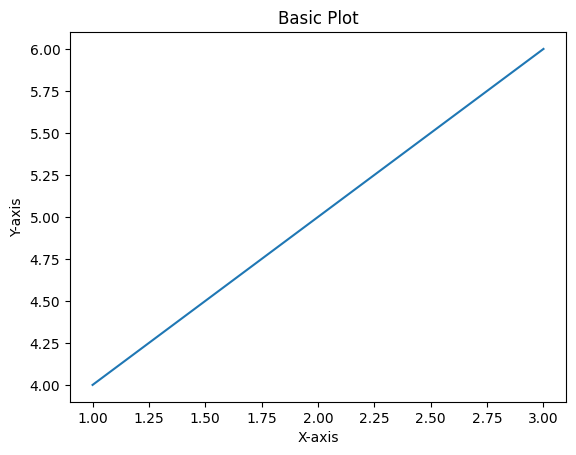

In [5]:
# craete a figure with a single axis
x= [1,2,3]

y= [4,5,6]

fig, ax = plt.subplots()
ax.plot(x,y)
ax.set_title ("Basic Plot")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")

plt.show()

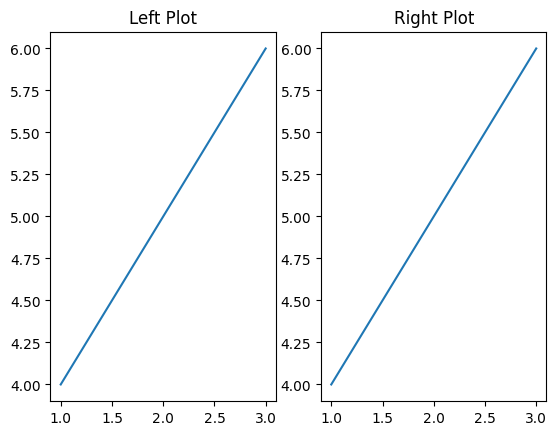

In [8]:
# create a figure with multiple subplots

fig, ax = plt.subplots(1,2) # PLOTS side by side
ax[0].plot(x,y)
ax[0].set_title("Left Plot")
ax[1]. plot(x,y)
ax[1].set_title("Right Plot")

plt.show()

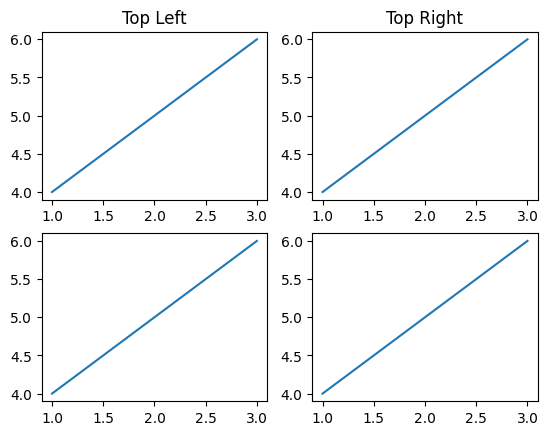

In [11]:
fig, ax = plt.subplots(2,2)
ax[0,0].plot(x,y)
ax[0,0].set_title("Top Left")
ax[0,1].plot(x,y)
ax[0,1].set_title("Top Right")
ax[1,0].plot(x,y)
ax[1,1].plot(x,y)

plt.show()

## EXPLORATORY DATA ANALYSIS

- Univariate Analysis: Examining one variable at at time

In [1]:
from google.colab import files
uploaded = files.upload()


Saving netflix_titles (2).csv to netflix_titles (2).csv


In [3]:
import pandas as pd
df = pd.read_csv('/content/netflix_titles (2).csv')


In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


What are the number of Neflix titles released per year?

In [8]:
tiltle_per_year = df.groupby('release_year') ['title'].count().reset_index()

tiltle_per_year

,release_year,title
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4
...,...,...
69,2017,1032
70,2018,1147
71,2019,1030
72,2020,953


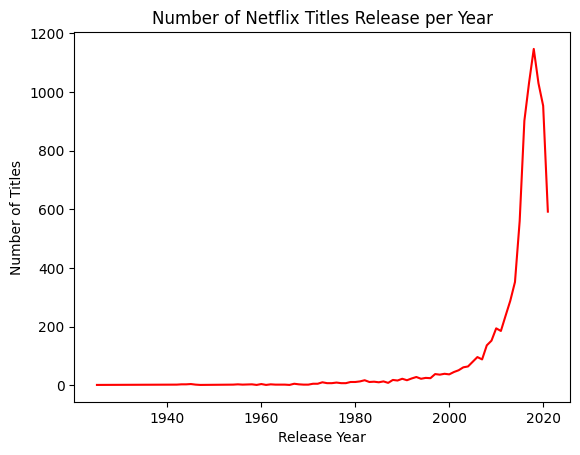

In [16]:
#Line plot
plt.plot(tiltle_per_year['release_year'],tiltle_per_year['title'], color = "red")

plt.title('Number of Netflix Titles Release per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

In [18]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [19]:
type_counts = df['type'].value_counts()
type_counts.index

Index(['Movie', 'TV Show'], dtype='object', name='type')

In [20]:
type_counts

,count
type,
Movie,6131
TV Show,2676


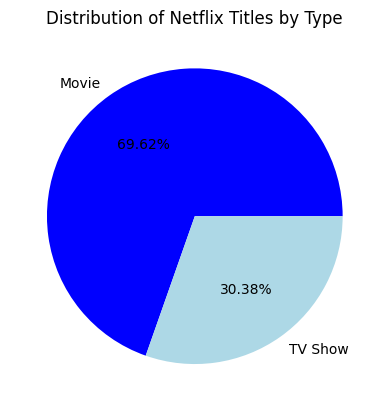

In [25]:
plt.pie(type_counts, labels=type_counts.index, autopct='%1.2f%%', colors=['blue', 'lightblue'])
plt.title('Distribution of Netflix Titles by Type')
plt.show()

In [26]:
df['rating']

,rating
0,PG-13
1,TV-MA
2,TV-MA
3,TV-MA
4,TV-MA
...,...
8802,R
8803,TV-Y7
8804,R
8805,PG


In [28]:
df['rating'] = df['rating'].replace({'74 min' : 'Unknown','84 min' : 'Unknown', '66 min' : 'Unknown'})

In [29]:
rating_counts = df['rating'].value_counts()
rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [30]:
rating_counts.index

Index(['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'TV-Y7', 'TV-Y', 'PG', 'TV-G',
       'NR', 'G', 'TV-Y7-FV', 'NC-17', 'Unknown', 'UR'],
      dtype='object', name='rating')

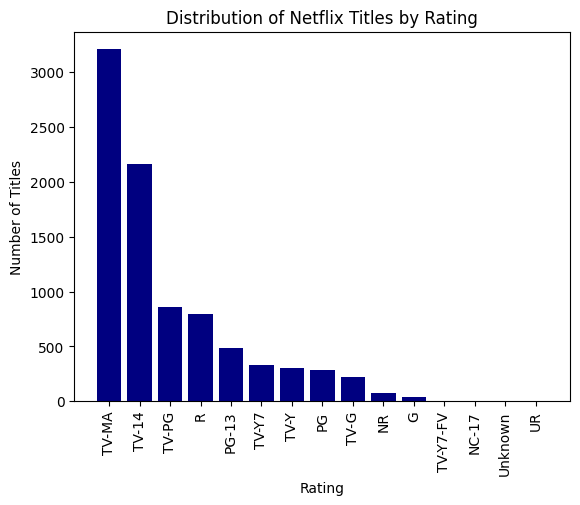

In [35]:
plt.bar(rating_counts.index, rating_counts.values, color='navy')

plt.xticks(rotation=90)
plt.title('Distribution of Netflix Titles by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')

plt.show()

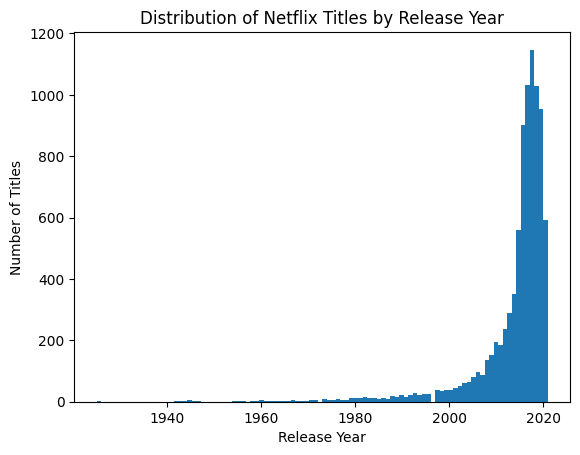

In [40]:
# Histogram is used to show distrivution of Numerical Variable

plt.hist(df['release_year'], bins= 100)

plt.title('Distribution of Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

In [41]:
df.shape

(8807, 12)

In [42]:
df['cast']. value_counts()

,count
cast,
David Attenborough,19
"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil",14
Samuel West,10
Jeff Dunham,7
"Michela Luci, Jamie Watson, Eric Peterson, Anna Claire Bartlam, Nicolas Aqui, Cory Doran, Julie Lemieux, Derek McGrath",6
...,...
"Toyin Abraham, Sambasa Nzeribe, Chioma Chukwuka Akpotha, Chioma Omeruah, Chiwetalu Agu, Dele Odule, Femi Adebayo, Bayray McNwizu, Biodun Stephen",1
"Neeraj Kabi, Geetanjali Kulkarni, Danish Husain, Sheeba Chaddha, Paras Priyadarshan, Anshul Chauhan, Anud Singh Dhaka, Shirin Sewani, Mihir Ahuja, Vasundhara Rajput",1
"Sanjay Dutt, Arjun Kapoor, Kriti Sanon, Zeenat Aman, Mohnish Bahl, Padmini Kolhapure, Kunal Kapoor, Suhasini Mulay",1


In [43]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [48]:
all_cast = df['cast'].dropna().str.split(',').explode().str.strip()
all_cast


,cast
1,Ama Qamata
1,Khosi Ngema
1,Gail Mabalane
1,Thabang Molaba
1,Dillon Windvogel
...,...
8806,Manish Chaudhary
8806,Meghna Malik
8806,Malkeet Rauni
8806,Anita Shabdish


In [49]:
all_cast.value_counts()

,count
cast,
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Takahiro Sakurai,32
Naseeruddin Shah,32
...,...
Tejashree Pradhan,1
Neha Joshi,1
Ayesha Omer,1


In [50]:
# top 10 cast that have featured the most on neflix for the past 10 years

cast_counts = all_cast.value_counts().head(10)
cast_counts

,count
cast,
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Takahiro Sakurai,32
Naseeruddin Shah,32
Rupa Bhimani,31
Om Puri,30
Akshay Kumar,30
Yuki Kaji,29


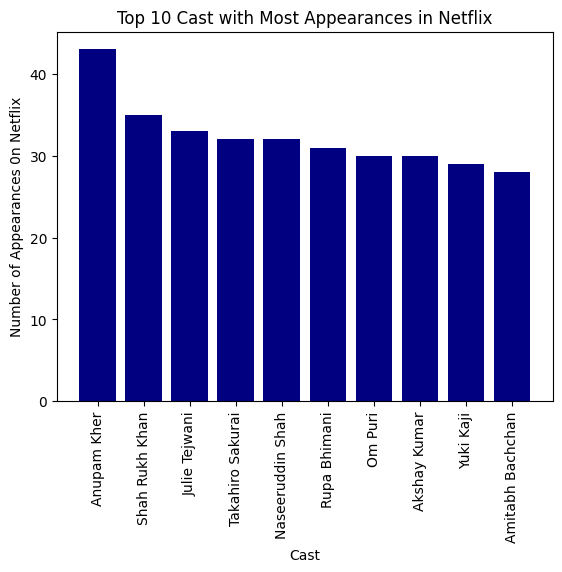

In [54]:
plt.bar(cast_counts.index, cast_counts.values, color='navy')

plt.xticks(rotation=90)
plt.title('Top 10 Cast with Most Appearances in Netflix')
plt.xlabel('Cast')
plt.ylabel('Number of Appearances 0n Netflix')

plt.show()

Bivariate Analysis

- Examining the relationship between 2 variables


In [55]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [63]:
# movies and TV shows released per year

release_year_by_type = df.groupby(['release_year', 'type']).size().unstack(fill_value=0).reset_index()
release_year_by_type

type,release_year,Movie,TV Show
0,1925,0,1
1,1942,2,0
2,1943,3,0
3,1944,3,0
4,1945,3,1
...,...,...,...
69,2017,767,265
70,2018,767,380
71,2019,633,397
72,2020,517,436


In [65]:
df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

type,Movie,TV Show
release_year,,
1925,0,1
1942,2,0
1943,3,0
1944,3,0
1945,3,1
...,...,...
2017,767,265
2018,767,380
2019,633,397


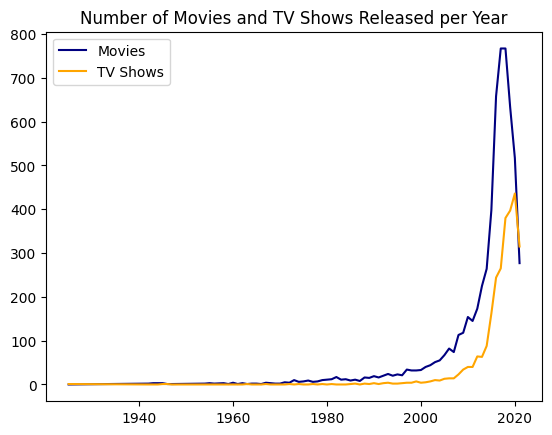

In [76]:
plt.plot (release_year_by_type['release_year'], release_year_by_type ['Movie'], label = 'Movies', color='navy')
plt.plot(release_year_by_type['release_year'], release_year_by_type ['TV Show'], label = 'TV Shows', color = 'orange')

plt.title('Number of Movies and TV Shows Released per Year')
plt.legend()